In [1]:
import gc
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.style.use('seaborn-v0_8')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

PROJECT_DIR = Path('.') if Path('datasets').exists() else Path('Текущий контроль 13-14')
DATA_DIR = PROJECT_DIR / 'datasets'
NAMES_PATH = DATA_DIR / 'name_rus.txt'
TEXT_PATH = DATA_DIR / 'The-Great-Gatsby.txt'
MODELS_DIR = PROJECT_DIR / 'saved_models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)


def clear_memory(*objects):
    for obj in objects:
        del obj
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def read_names(path):
    for encoding in ('cp1251', 'utf-8', 'latin1'):
        try:
            text = path.read_text(encoding=encoding)
            lines = [line.strip().lower() for line in text.splitlines() if line.strip()]
            if lines:
                print(f'names encoding: {encoding}, count={len(lines)}')
                return lines
        except UnicodeDecodeError:
            continue
    raise ValueError(f'Не удалось прочитать файл имен: {path}')


def normalize_book_text(text):
    text = text.replace('\r', ' ')
    text = text.replace('“', '"').replace('”', '"').replace('’', "'")
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


class CharVocab:
    def __init__(self, texts, specials=None):
        self.itos = []
        for token in specials or []:
            if token not in self.itos:
                self.itos.append(token)
        chars = sorted({ch for text in texts for ch in text})
        for ch in chars:
            if ch not in self.itos:
                self.itos.append(ch)
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}
        self.pad_idx = self.stoi.get('<PAD>')
        self.unk_idx = self.stoi.get('<UNK>')
        self.sos_idx = self.stoi.get('<SOS>')
        self.eos_idx = self.stoi.get('<EOS>')

    def encode(self, text, add_special_tokens=False):
        ids = []
        if add_special_tokens and self.sos_idx is not None:
            ids.append(self.sos_idx)
        for ch in text:
            if ch in self.stoi:
                ids.append(self.stoi[ch])
            elif self.unk_idx is not None:
                ids.append(self.unk_idx)
        if add_special_tokens and self.eos_idx is not None:
            ids.append(self.eos_idx)
        return ids

    def decode(self, ids, skip_special=True):
        pieces = []
        for idx in ids:
            token = self.itos[idx]
            if skip_special and token.startswith('<') and token.endswith('>'):
                continue
            pieces.append(token)
        return ''.join(pieces)

    def __len__(self):
        return len(self.itos)


class NameDataset(Dataset):
    def __init__(self, names, vocab):
        self.samples = [vocab.encode(name, add_special_tokens=True) for name in names]
        self.pad_idx = vocab.pad_idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq = self.samples[idx]
        x = torch.tensor(seq[:-1], dtype=torch.long)
        y = torch.tensor(seq[1:], dtype=torch.long)
        return x, y


class TextChunkDataset(Dataset):
    def __init__(self, encoded_text, seq_len, step=None):
        self.sequences = []
        step = step or seq_len
        for start in range(0, max(len(encoded_text) - seq_len - 1, 0), step):
            chunk = encoded_text[start:start + seq_len + 1]
            if len(chunk) == seq_len + 1:
                self.sequences.append(chunk)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        chunk = self.sequences[idx]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y


def make_pad_collate(pad_idx):
    def collate(batch):
        xs, ys = zip(*batch)
        max_len = max(x.size(0) for x in xs)
        batch_x = torch.full((len(batch), max_len), pad_idx, dtype=torch.long)
        batch_y = torch.full((len(batch), max_len), pad_idx, dtype=torch.long)
        for i, (x, y) in enumerate(zip(xs, ys)):
            batch_x[i, :x.size(0)] = x
            batch_y[i, :y.size(0)] = y
        return batch_x, batch_y
    return collate


class CharRNNGenerator(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, pad_idx=None, num_layers=1, rnn_type='gru'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        if rnn_type == 'rnn':
            self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True, num_layers=num_layers)
        elif rnn_type == 'lstm':
            self.rnn = nn.LSTM(embedding_dim, hidden_size, batch_first=True, num_layers=num_layers)
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(embedding_dim, hidden_size, batch_first=True, num_layers=num_layers)
        else:
            raise ValueError(f'unknown rnn_type: {rnn_type}')
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.rnn_type = rnn_type

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        output, hidden = self.rnn(emb, hidden)
        logits = self.fc(output)
        return logits, hidden


def train_language_model(model, train_loader, criterion, optimizer, epochs, device, pad_idx=None, grad_clip=None, sample_fn=None, sample_every=5):
    history = {'loss': []}
    model.to(device)
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_tokens = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits, _ = model(X_batch)
            logits = logits.reshape(-1, logits.size(-1))
            targets = y_batch.reshape(-1)
            loss = criterion(logits, targets)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            if pad_idx is None:
                token_count = targets.numel()
            else:
                token_count = (targets != pad_idx).sum().item()
            total_loss += loss.item() * max(token_count, 1)
            total_tokens += max(token_count, 1)
        avg_loss = total_loss / max(total_tokens, 1)
        history['loss'].append(avg_loss)
        print(f'epoch {epoch}/{epochs}: loss={avg_loss:.4f}')
        if sample_fn is not None and (epoch == 1 or epoch % sample_every == 0 or epoch == epochs):
            print('samples:')
            for sample in sample_fn():
                print(sample)
            print('---')
    return history


def plot_loss(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history['loss'])
    plt.title(title)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()


def sample_name(model, vocab, max_len=20, temperature=0.9):
    model.eval()
    generated = [vocab.sos_idx]
    hidden = None
    current = torch.tensor([[vocab.sos_idx]], dtype=torch.long, device=device)
    with torch.no_grad():
        for _ in range(max_len):
            logits, hidden = model(current, hidden)
            next_logits = logits[:, -1, :] / temperature
            probs = torch.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            token_id = int(next_token.item())
            if token_id == vocab.eos_idx:
                break
            if token_id != vocab.pad_idx:
                generated.append(token_id)
            current = next_token
    return vocab.decode(generated[1:])


def sample_text(model, vocab, prime='Gatsby', max_new_tokens=250, temperature=0.8):
    model.eval()
    prime_ids = vocab.encode(prime)
    if not prime_ids:
        prime_ids = [0]
    hidden = None
    current = torch.tensor([prime_ids], dtype=torch.long, device=device)
    generated = prime_ids[:]
    with torch.no_grad():
        logits, hidden = model(current, hidden)
        current = current[:, -1:]
        for _ in range(max_new_tokens):
            logits, hidden = model(current, hidden)
            next_logits = logits[:, -1, :] / temperature
            probs = torch.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            token_id = int(next_token.item())
            generated.append(token_id)
            current = next_token
    return vocab.decode(generated, skip_special=False)


device: cuda:0


In [2]:
print('PROJECT_DIR =', PROJECT_DIR.resolve())
print('NAMES_PATH exists =', NAMES_PATH.exists(), NAMES_PATH)
print('TEXT_PATH exists =', TEXT_PATH.exists(), TEXT_PATH)
name_preview = read_names(NAMES_PATH)[:10]
print('name sample:', name_preview)
book_text = normalize_book_text(TEXT_PATH.read_text(encoding='utf-8', errors='ignore'))
print('book chars:', len(book_text))
print('book preview:', repr(book_text[:250]))


PROJECT_DIR = /home/aleksey/Documents/mirea_lab/6 sem/algo-ml/Текущий контроль 13-14
NAMES_PATH exists = True datasets/name_rus.txt
TEXT_PATH exists = True datasets/The-Great-Gatsby.txt
names encoding: cp1251, count=1988
name sample: ['авдокея', 'авдоким', 'авдоня', 'авдотька', 'авдотьюшка', 'авдотья', 'авдоха', 'авдоша', 'авдуля', 'авдуся']
book chars: 264643
book preview: 'CHAPTER I In my younger and more vulnerable years my father gave me some advice that I\'ve been turning over in my mind ever since."Whenever you feel like criticizing any one," he told me, "just remember that all the people in this world haven\'t had t'


## 1. Генерирование русских имен при помощи RNN


Датасет: https://disk.yandex.ru/i/2yt18jHUgVEoIw

1.1 На основе файла name_rus.txt создайте датасет.
  * Учтите, что имена могут иметь различную длину
  * Добавьте 4 специальных токена: 
    * `<PAD>` для дополнения последовательности до нужной длины;
    * `<UNK>` для корректной обработки ранее не встречавшихся токенов;
    * `<SOS>` для обозначения начала последовательности;
    * `<EOS>` для обозначения конца последовательности.
  * Преобразовывайте строку в последовательность индексов с учетом следующих замечаний:
    * в начало последовательности добавьте токен `<SOS>`;
    * в конец последовательности добавьте токен `<EOS>` и, при необходимости, несколько токенов `<PAD>`;
  * `Dataset.__get_item__` возращает две последовательности: последовательность для обучения и правильный ответ. 
  
  Пример:
  ```
  s = 'The cat sat on the mat'
  # преобразуем в индексы
  s_idx = [2, 5, 1, 2, 8, 4, 7, 3, 0, 0]
  # получаем x и y (__getitem__)
  x = [2, 5, 1, 2, 8, 4, 7, 3, 0]
  y = [5, 1, 2, 8, 4, 7, 3, 0, 0]
  ```

1.2 Создайте и обучите модель для генерации фамилии.

  * Для преобразования последовательности индексов в последовательность векторов используйте `nn.Embedding`;
  * Используйте рекуррентные слои;
  * Задача ставится как предсказание следующего токена в каждом примере из пакета для каждого момента времени. Т.е. в данный момент времени по текущей подстроке предсказывает следующий символ для данной строки (задача классификации);
  * Примерная схема реализации метода `forward`:
  ```
    input_X: [batch_size x seq_len] -> nn.Embedding -> emb_X: [batch_size x seq_len x embedding_size]
    emb_X: [batch_size x seq_len x embedding_size] -> nn.RNN -> output: [batch_size x seq_len x hidden_size] 
    output: [batch_size x seq_len x hidden_size] -> torch.Tensor.reshape -> output: [batch_size * seq_len x hidden_size]
    output: [batch_size * seq_len x hidden_size] -> nn.Linear -> output: [batch_size * seq_len x vocab_size]
  ```

1.3 Напишите функцию, которая генерирует фамилию при помощи обученной модели:
  * Построение начинается с последовательности единичной длины, состоящей из индекса токена `<SOS>`;
  * Начальное скрытое состояние RNN `h_t = None`;
  * В результате прогона последнего токена из построенной последовательности через модель получаете новое скрытое состояние `h_t` и распределение над всеми токенами из словаря;
  * Выбираете 1 токен пропорционально вероятности и добавляете его в последовательность (можно воспользоваться `torch.multinomial`);
  * Повторяете эти действия до тех пор, пока не сгенерирован токен `<EOS>` или не превышена максимальная длина последовательности.

При обучении каждые `k` эпох генерируйте несколько фамилий и выводите их на экран.


names encoding: cp1251, count=1988
names count: 1988
name vocab size: 34
example encoded: (tensor([ 2,  4,  6,  8, 18, 14,  9, 33]), tensor([ 4,  6,  8, 18, 14,  9, 33,  3]))
epoch 1/20: loss=3.3316
samples:
тоержлеьтго
мшблаюашо
книаял
еьеманелявшжан
твшрасмушяншг
---
epoch 2/20: loss=2.7960
epoch 3/20: loss=2.5366
epoch 4/20: loss=2.3604
epoch 5/20: loss=2.2264
samples:
йееоуша
гелелкхсис
еомиля
сешайя
итенаса
---
epoch 6/20: loss=2.1310
epoch 7/20: loss=2.0631
epoch 8/20: loss=2.0049
epoch 9/20: loss=1.9593
epoch 10/20: loss=1.9169
samples:
ниросий
татья
тасяринка
лола
виося
---
epoch 11/20: loss=1.8788
epoch 12/20: loss=1.8428
epoch 13/20: loss=1.8094
epoch 14/20: loss=1.7777
epoch 15/20: loss=1.7471
samples:
мила
егуня
даксян
вася
ароричнка
---
epoch 16/20: loss=1.7191
epoch 17/20: loss=1.6913
epoch 18/20: loss=1.6660
epoch 19/20: loss=1.6401
epoch 20/20: loss=1.6185
samples:
зашрилыч
маленя
агуля
арнонич
вастена
---


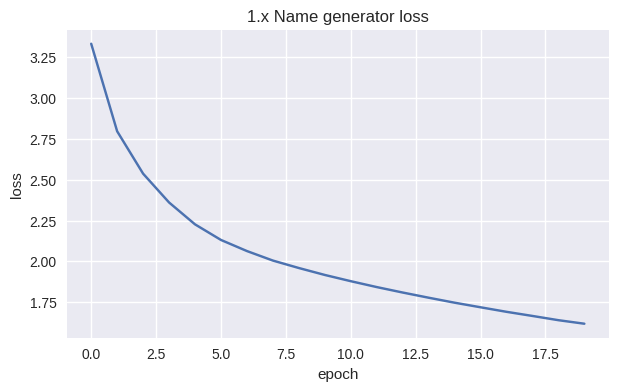

Generated names:
антера
мантиша
алекся
колина
иляха
митуха
евлинусяка
ведоля
митаха
настимилыч


In [3]:
names = read_names(NAMES_PATH)
name_vocab = CharVocab(names, specials=['<PAD>', '<UNK>', '<SOS>', '<EOS>'])
name_dataset = NameDataset(names, name_vocab)
name_loader = DataLoader(
    name_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=make_pad_collate(name_vocab.pad_idx),
)

print('names count:', len(names))
print('name vocab size:', len(name_vocab))
print('example encoded:', name_dataset[0])

name_model = CharRNNGenerator(
    vocab_size=len(name_vocab),
    embedding_dim=32,
    hidden_size=128,
    pad_idx=name_vocab.pad_idx,
    num_layers=1,
    rnn_type='gru',
).to(device)
name_criterion = nn.CrossEntropyLoss(ignore_index=name_vocab.pad_idx)
name_optimizer = optim.Adam(name_model.parameters(), lr=1e-3)

history_names = train_language_model(
    name_model,
    name_loader,
    name_criterion,
    name_optimizer,
    epochs=20,
    device=device,
    pad_idx=name_vocab.pad_idx,
    grad_clip=1.0,
    sample_fn=lambda: [sample_name(name_model, name_vocab, max_len=18, temperature=0.8) for _ in range(5)],
    sample_every=5,
)
plot_loss(history_names, '1.x Name generator loss')

print('Generated names:')
for _ in range(10):
    print(sample_name(name_model, name_vocab, max_len=18, temperature=0.75))

torch.save({
    'model_state': name_model.state_dict(),
    'vocab': name_vocab.itos,
}, MODELS_DIR / 'name_generator_gru.pth')


## 2. Генерирование текста при помощи RNN

2.1 Скачайте из интернета какое-нибудь художественное произведение
  * Выбирайте достаточно крупное произведение, чтобы модель лучше обучалась;

2.2 На основе выбранного произведения создайте датасет. 

Отличия от задачи 1:
  * Токены <SOS>, `<EOS>` и `<UNK>` можно не добавлять;
  * При создании датасета текст необходимо предварительно разбить на части. Выберите желаемую длину последовательности `seq_len` и разбейте текст на построки длины `seq_len` (можно без перекрытия, можно с небольшим перекрытием).

2.3 Создайте и обучите модель для генерации текста
  * Задача ставится точно так же как в 1.2;
  * При необходимости можете применить:
    * двухуровневые рекуррентные слои (`num_layers`=2)
    * [обрезку градиентов](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html)

2.4 Напишите функцию, которая генерирует фрагмент текста при помощи обученной модели
  * Процесс генерации начинается с небольшого фрагмента текста `prime`, выбранного вами (1-2 слова) 
  * Сначала вы пропускаете через модель токены из `prime` и генерируете на их основе скрытое состояние рекуррентного слоя `h_t`;
  * После этого вы генерируете строку нужной длины аналогично 1.3


text vocab size: 80
text dataset size: 4409
seq_len: 120
epoch 1/15: loss=2.8902
samples:
Gatsby I the cid short hen ther sas t the fer, ae. rbas saty hald wos, aos them thint the ped illes rathu fo custh t ine lhaputce asseken ceom if he tolde Llod en hat Hant illher tas, ar 
---
epoch 2/15: loss=2.1657
epoch 3/15: loss=1.8624
samples:
Gatsby opread somether could, Tom over a pach the pask Dnoked as you it was tome pentedenoon, a car of alore. Oched with a cart and surray, in the miss perlight. The sieven side it supidi
---
epoch 4/15: loss=1.6876
epoch 5/15: loss=1.5709
epoch 6/15: loss=1.4851
samples:
Gatsby and with achead short man and blue. Sure the blue figurate what he looking gleam, and a faintly, "ull, and an his hall same out this might down were seemed the shalled as me now he
---
epoch 7/15: loss=1.4186
epoch 8/15: loss=1.3624
epoch 9/15: loss=1.3157
samples:
Gatsby abmody. You remembered it story of colday and conseeting him he could crom of the circing with an elabary ha

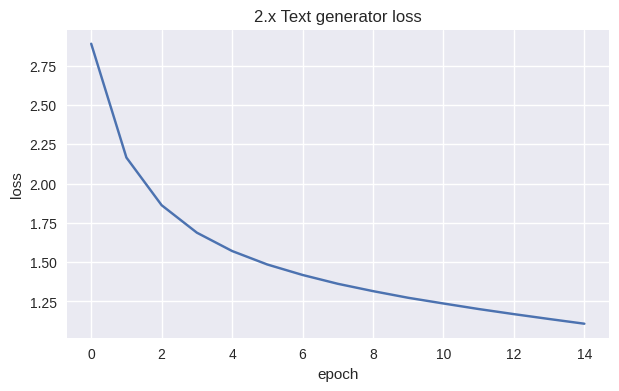

Generated fragments:
Gatsby and wanted to not a week and his mouth. A think of the beback a rather thing—without alone.But Tom Buchanan and a superior than the humb he began to get alones, the end.Mrsward a while or summer in seemed pale, standing into the bid chanked with an incessant was waves of a single-raid slowly doubtle
---
In the and what he kissed him wants and incopper on now I'd been creep, one of which was just as the table earnestly there so known the garage, between every opened I felt that he supper and away at her are the girdon, and Mrs. With an hour Mr. Gatsby, began for a heart. Good was to Gatsby's face flashed s


In [4]:
book_text = normalize_book_text(TEXT_PATH.read_text(encoding='utf-8', errors='ignore'))
text_vocab = CharVocab([book_text], specials=[])
encoded_book = text_vocab.encode(book_text)
seq_len = 120
text_dataset = TextChunkDataset(encoded_book, seq_len=seq_len, step=60)
text_loader = DataLoader(text_dataset, batch_size=64, shuffle=True)

print('text vocab size:', len(text_vocab))
print('text dataset size:', len(text_dataset))
print('seq_len:', seq_len)

text_model = CharRNNGenerator(
    vocab_size=len(text_vocab),
    embedding_dim=64,
    hidden_size=256,
    pad_idx=None,
    num_layers=2,
    rnn_type='gru',
).to(device)
text_criterion = nn.CrossEntropyLoss()
text_optimizer = optim.Adam(text_model.parameters(), lr=1e-3)

history_text = train_language_model(
    text_model,
    text_loader,
    text_criterion,
    text_optimizer,
    epochs=15,
    device=device,
    pad_idx=None,
    grad_clip=1.0,
    sample_fn=lambda: [sample_text(text_model, text_vocab, prime='Gatsby ', max_new_tokens=180, temperature=0.85)],
    sample_every=3,
)
plot_loss(history_text, '2.x Text generator loss')

print('Generated fragments:')
print(sample_text(text_model, text_vocab, prime='Gatsby ', max_new_tokens=300, temperature=0.82))
print('---')
print(sample_text(text_model, text_vocab, prime='In the ', max_new_tokens=300, temperature=0.82))

torch.save({
    'model_state': text_model.state_dict(),
    'vocab': text_vocab.itos,
}, MODELS_DIR / 'gatsby_generator_gru.pth')

name_model.cpu()
clear_memory(name_model, name_optimizer, history_names)
